# Session 1 — Solutions

This notebook contains worked solutions for Session 1.

### Exercise 1.1 — Load and inspect a NanoAOD file


In [1]:
import sys
sys.path.append("..")
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

from coffea.nanoevents import NanoEventsFactory, NanoAODSchema

def load_events(filepath):
    """Load one NanoAOD ROOT file and return a NanoEvents object.

    - **Why NanoEvents?** It maps flat NanoAOD branches like `Jet_pt`, `MET_pt` into
      convenient collections like `events.Jet.pt`, `events.MET.pt` using Awkward Arrays.
    """
    return NanoEventsFactory.from_root(filepath, schemaclass=NanoAODSchema).events()

# Load events
from config.datasets_2017 import get_one_file_per_group_from_yaml
try:
    files = get_one_file_per_group_from_yaml()
    # We load one *data* file (MET run) and one *MC background* file.
    events_data = load_events(files["data"][0])
    events = load_events(files["background"][0])
    print("Files Loaded:\n",files)
except Exception as e:
    print("Could not load events.")
    print(e)

Files Loaded:
 {'data': ['/eos/cms/store/group/phys_susy/sus-23-008/cmsdas2026/2017/SingleElectron-Run2017B-02Apr2020-v1/0ACA0341-E365-2544-99F0-FBA4C92C0301.root'], 'background': ['/eos/cms/store/group/phys_susy/sus-23-008/cmsdas2026/2017/ST_t-channel_top_4f_inclusiveDecays_TuneCP5_13TeV-powhegV2-madspin-pythia8-RunIIFall17NanoAOD-PU2017_12Apr2018_94X_mc2017_realistic_v14-v1/1CDD2975-0843-E811-BE66-0242AC130002.root']}


/cvmfs/sft.cern.ch/lcg/views/LCG_105a_swan/x86_64-el9-gcc13-opt/lib/python3.9/site-packages/coffea/nanoevents/schemas/nanoaod.py:201: RuntimeWarning: Missing cross-reference index for FatJet_genJetAK8Idx => GenJetAK8
  warnings.warn(
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_swan/x86_64-el9-gcc13-opt/lib/python3.9/site-packages/coffea/nanoevents/schemas/nanoaod.py:201: RuntimeWarning: Missing cross-reference index for FsrPhoton_muonIdx => Muon
  warnings.warn(
/cvmfs/sft.cern.ch/lcg/views/LCG_105a_swan/x86_64-el9-gcc13-opt/lib/python3.9/site-packages/coffea/nanoevents/schemas/nanoaod.py:201: RuntimeWarning: Missing cross-reference index for Muon_fsrPhotonIdx => FsrPhoton
  warnings.warn(


In [2]:
# Run/Lumi/Event numbers uniquely identify events in CMS data.
print("Total number of events:", len(events))
print("run (first 5):", events.run[:5])
print("luminosityBlock (first 5):", events.luminosityBlock[:5])
print("event (first 5):", events.event[:5])

Total number of events: 42598
run (first 5): [1, 1, 1, 1, 1]
luminosityBlock (first 5): [325, 325, 325, 325, 325]
event (first 5): [181609, 181605, 181607, 181618, 181617]


In [3]:
print("MET fields:", events.MET.fields)
print("Jet fields:", events.Jet.fields)
print("MET: ", events.MET.pt[:5], "... (first 5 events)")
print("Number of jets per event (first 10):", ak.num(events.Jet)[:10])

MET fields: ['MetUnclustEnUpDeltaX', 'MetUnclustEnUpDeltaY', 'covXX', 'covXY', 'covYY', 'phi', 'pt', 'significance', 'sumEt', 'fiducialGenPhi', 'fiducialGenPt']
Jet fields: ['area', 'btagCMVA', 'btagCSVV2', 'btagDeepB', 'btagDeepC', 'btagDeepFlavB', 'chEmEF', 'chHEF', 'eta', 'mass', 'neEmEF', 'neHEF', 'phi', 'pt', 'qgl', 'rawFactor', 'bReg', 'electronIdx1', 'electronIdx2', 'jetId', 'muonIdx1', 'muonIdx2', 'nConstituents', 'nElectrons', 'nMuons', 'puId', 'genJetIdx', 'hadronFlavour', 'partonFlavour', 'cleanmask', 'electronIdx1G', 'electronIdx2G', 'genJetIdxG', 'muonIdx1G', 'muonIdx2G', 'muonIdxG', 'electronIdxG']
MET:  [62.3, 181, 67.5, 28, 29.5] ... (first 5 events)
Number of jets per event (first 10): [6, 8, 3, 7, 4, 9, 7, 8, 7, 6]


### Exercise 1.2 — MET plotting

As a first example of plotting with matplotlib, make a simple MET distribution using the loaded `events` object.

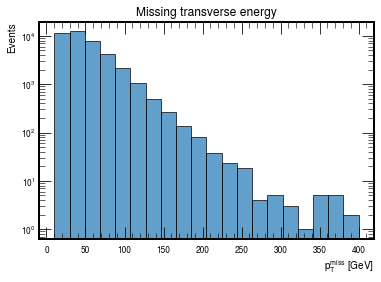

In [4]:
import mplhep as hep
hep.style.use("CMS")
# MET (pTmiss) is defined in the transverse plane and acts as a proxy for invisible particles that escape the detector (neutrinos / DM).
met = events.MET.pt

# Convert Awkward Array → NumPy for matplotlib.
plt.figure()
plt.hist(ak.to_numpy(met), bins=20, range=(10, 400), edgecolor="black", alpha=0.7)
plt.yscale('log')
plt.xlabel("p$_{T}^{miss}$ [GeV]")
plt.ylabel("Events")
plt.title("Missing transverse energy")
plt.show()

### Exercise 1.3 — Trigger OR

Build the trigger OR mask from `events.HLT` using the configured trigger list, print how many events pass, and compare MET before/after trigger.

Events passing at least one analysis trigger: 5445 / 42598
  run=1 lumi=325 event=181605 MET=181 GeV  fired: ['PFMETNoMu120_PFMHTNoMu120_IDTight_PFHT60', 'PFMETNoMu120_PFMHTNoMu120_IDTight']
  run=1 lumi=325 event=181613 MET=38 GeV  fired: ['Ele27_WPTight_Gsf', 'Ele32_WPTight_Gsf_L1DoubleEG', 'Ele32_WPTight_Gsf']...
  run=1 lumi=325 event=181610 MET=76 GeV  fired: ['IsoMu24', 'IsoMu27']
  run=1 lumi=325 event=181614 MET=68 GeV  fired: ['IsoMu24', 'IsoMu27']
  run=1 lumi=325 event=181616 MET=29 GeV  fired: ['IsoMu24', 'IsoMu27']
  run=1 lumi=325 event=181620 MET=88 GeV  fired: ['Ele27_WPTight_Gsf', 'Ele32_WPTight_Gsf_L1DoubleEG', 'Ele32_WPTight_Gsf']...
  run=1 lumi=325 event=181622 MET=103 GeV  fired: ['Ele27_WPTight_Gsf']
  run=1 lumi=325 event=181621 MET=41 GeV  fired: ['IsoMu24', 'IsoMu27']
  run=1 lumi=325 event=181644 MET=38 GeV  fired: ['IsoMu24', 'IsoMu27']
  run=1 lumi=325 event=181630 MET=100 GeV  fired: ['IsoMu24', 'IsoMu27']


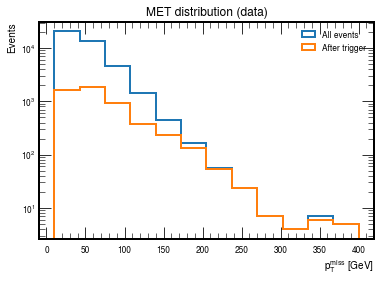

In [5]:
# Exercise 1.2: Trigger OR + MET plot
# In the analysis we require events to pass at least one HLT path from the configured trigger list.
from config.datasets_2017 import get_trigger_list

# Use data by default (switch to `events` for MC)
ev = events

trigger_list = get_trigger_list()
hlt_fields = set(ev.HLT.fields) if hasattr(ev, "HLT") and hasattr(ev.HLT, "fields") else set()

trigger_mask = ak.zeros_like(ev.event, dtype=bool)
for tname in trigger_list:
    if tname in hlt_fields:
        trigger_mask = trigger_mask | ev.HLT[tname]

n_pass = int(ak.sum(trigger_mask))
print("Events passing at least one analysis trigger:", n_pass, "/", len(ev))

# Show a few passing events
passing = ev[trigger_mask]
n_show = min(10, len(passing))
for i in range(n_show):
    evi = passing[i]
    fired = [t for t in trigger_list if (t in evi.HLT.fields and bool(evi.HLT[t]))]
    print(f"  run={int(evi.run)} lumi={int(evi.luminosityBlock)} event={int(evi.event)} MET={float(evi.MET.pt):.0f} GeV  fired: {fired[:3]}{'...' if len(fired)>3 else ''}")

# MET plot (optionally after trigger)
met = ev.MET.pt
met_pass = passing.MET.pt
plt.figure()
plt.hist(ak.to_numpy(met), bins=12, range=(10, 400), histtype="step", linewidth=2, label="All events")
plt.hist(ak.to_numpy(met_pass), bins=12, range=(10, 400), histtype="step", linewidth=2, label="After trigger")
plt.xlabel("p$_{T}^{miss}$ [GeV]")
plt.yscale('log')
plt.ylabel("Events")
plt.title("MET distribution (data)")
plt.legend()
plt.show()

### Exercise 1.4 — Jet pT

Fill a histogram of jet transverse momentum for all jets in the sample.

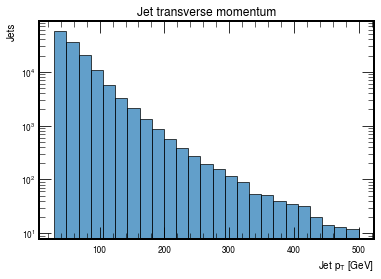

In [6]:
# Solution: jet pT histogram
# `events.Jet.pt` is *jagged* (variable number of jets per event).
# We flatten it to get one pT value per jet across all events.
jpt = ak.flatten(events.Jet.pt)

plt.figure()
plt.hist(ak.to_numpy(jpt), bins=25, range=(30, 500), edgecolor="black", alpha=0.7)
plt.xlabel("Jet p$_T$ [GeV]")
plt.ylabel("Jets")
plt.yscale('log')
plt.title("Jet transverse momentum")
plt.show()

### Exercise 1.5 — Jet multiplicity

Plot the distribution of the number of jets per event.

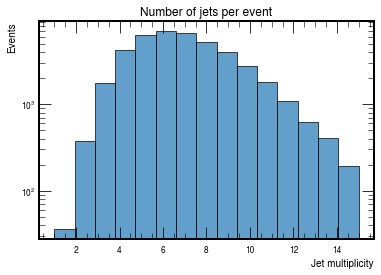

In [7]:
# Solution: jet multiplicity histogram
# `ak.num(events.Jet)` counts how many jets each event has.
# This stays per-event (we do NOT flatten), so the histogram is "events vs Njets".
njets = ak.num(events.Jet)

plt.figure()
plt.hist(ak.to_numpy(njets), bins=15, range=(1, 15), edgecolor="black", alpha=0.7)
plt.xlabel("Jet multiplicity")
plt.ylabel("Events")
plt.yscale('log')
plt.title("Number of jets per event")
plt.show()

### Exercise 1.6 — Lepton content

Inspect basic kinematics for electrons and muons using the loaded `events` object:
- Print the first few values of **pt, eta, and phi** for `events.Electron` and `events.Muon`.
- Count how many events have at least one electron or at least one muon.


In [8]:
# Solution: lepton content
# In NanoAOD, electrons and muons are stored as collections (jagged arrays).
# Printing the first few entries helps verify the branch mapping and units.
print("Electron pt (first 5 events):", events.Electron.pt[:5])
print("Electron eta (first 5 events):", events.Electron.eta[:5])
print("Electron phi (first 5 events):", events.Electron.phi[:5])

print("Muon pt (first 5 events):", events.Muon.pt[:5])
print("Muon eta (first 5 events):", events.Muon.eta[:5])
print("Muon phi (first 5 events):", events.Muon.phi[:5])

# Count leptons per event (axis=1 = along the per-event jagged dimension)
# This gives per-event multiplicities that we can threshold.
n_ele = ak.count(events.Electron.pt, axis=1)
n_mu = ak.count(events.Muon.pt, axis=1)
print("Events with >=1 electron:", ak.sum(n_ele >= 1))
print("Events with >=1 muon:", ak.sum(n_mu >= 1))

Electron pt (first 5 events): [[25.8], [14.6], [], [], [15.8, 10.7]]
Electron eta (first 5 events): [[1.84], [0.141], [], [], [-0.146, -0.0764]]
Electron phi (first 5 events): [[1.83], [-2.65], [], [], [-0.944, -0.763]]
Muon pt (first 5 events): [[], [], [], [], []]
Muon eta (first 5 events): [[], [], [], [], []]
Muon phi (first 5 events): [[], [], [], [], []]
Events with >=1 electron: 21480
Events with >=1 muon: 14925


### Exercise 1.7 — Lepton kinematic plots

Make simple histograms of lepton kinematics:
- Plot pt for electrons and muons (e.g. 0–200 GeV),
- Plot eta for electrons and muons,
- Plot phi for electrons and muons.


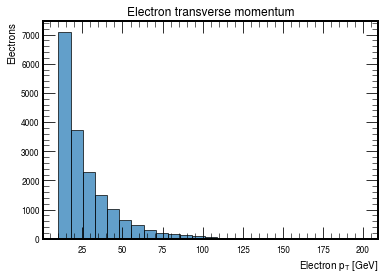

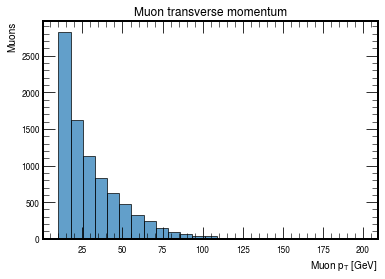

In [9]:
# Example solution: lepton kinematic histograms
# For kinematic distributions, we typically want one entry per lepton.
# Flatten the jagged collections (events × leptons) into a 1D array of leptons.
el_pt = ak.flatten(events.Electron.pt)
el_eta = ak.flatten(events.Electron.eta)
el_phi = ak.flatten(events.Electron.phi)

mu_pt = ak.flatten(events.Muon.pt)
mu_eta = ak.flatten(events.Muon.eta)
mu_phi = ak.flatten(events.Muon.phi)

# Electron pT
plt.figure()
plt.hist(ak.to_numpy(el_pt), bins=25, range=(10, 200), edgecolor="black", alpha=0.7)
plt.xlabel("Electron p$_T$ [GeV]")
plt.ylabel("Electrons")
plt.title("Electron transverse momentum")
plt.show()

# Muon pT
plt.figure()
plt.hist(ak.to_numpy(mu_pt), bins=25, range=(10, 200), edgecolor="black", alpha=0.7)
plt.xlabel("Muon p$_T$ [GeV]")
plt.ylabel("Muons")
plt.title("Muon transverse momentum")
plt.show()

# (Eta/phi plots would be analogous: use el_eta/mu_eta and el_phi/mu_phi.)